In [2]:
#importing the libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pylab import rcParams
import seaborn as sb

In [3]:
#import dataset 
import os
import openpyxl
pwd = os.getcwd()
dataset = pd.read_excel(pwd + "/data/DATA.xlsx")
dataset_copy = dataset.copy()
dataset_copy.head(4)

,Datetime,Date,Year,Month,Day,Time,Hour,Temperature,Holiday,Daytype,Frequency of use [Cooker],Frequency of use [Light],Frequency of use [Laptop],Frequency of use [Kettle],Frequency of use [Fan],Frequency of use [Ipod/Tab/Phone],Frequency of use in a day [Iron],Power
0,2022-09-01 00:00:00,2022-09-01,2022,9,1,00:00,0,23.82,1,Thursday,Low,Medium,Medium,Low,High,Medium,Low,NaN
1,2022-09-01 01:00:00,2022-09-01,2022,9,1,01:00,1,23.68,1,Thursday,Low,Medium,Medium,Low,High,Medium,Low,NaN
2,2022-09-01 02:00:00,2022-09-01,2022,9,1,02:00,2,23.61,1,Thursday,Low,Medium,Medium,Low,High,Medium,Low,NaN
3,2022-09-01 03:00:00,2022-09-01,2022,9,1,03:00,3,23.56,1,Thursday,Low,Medium,Medium,Low,High,Medium,Low,NaN


In [158]:
#run when modeling-alternative
dataset_copy.drop(['Time', 'Date'], inplace=True, axis=1)

In [175]:
#run when modeling
dataset_copy.drop(['Time', 'Date', 'Frequency of use [Cooker]',	'Frequency of use [Light]',	'Frequency of use [Laptop]','Frequency of use [Kettle]',	'Frequency of use [Fan]'	,'Frequency of use [Ipod/Tab/Phone]',	'Frequency of use in a day [Iron]'	], inplace=True, axis=1)

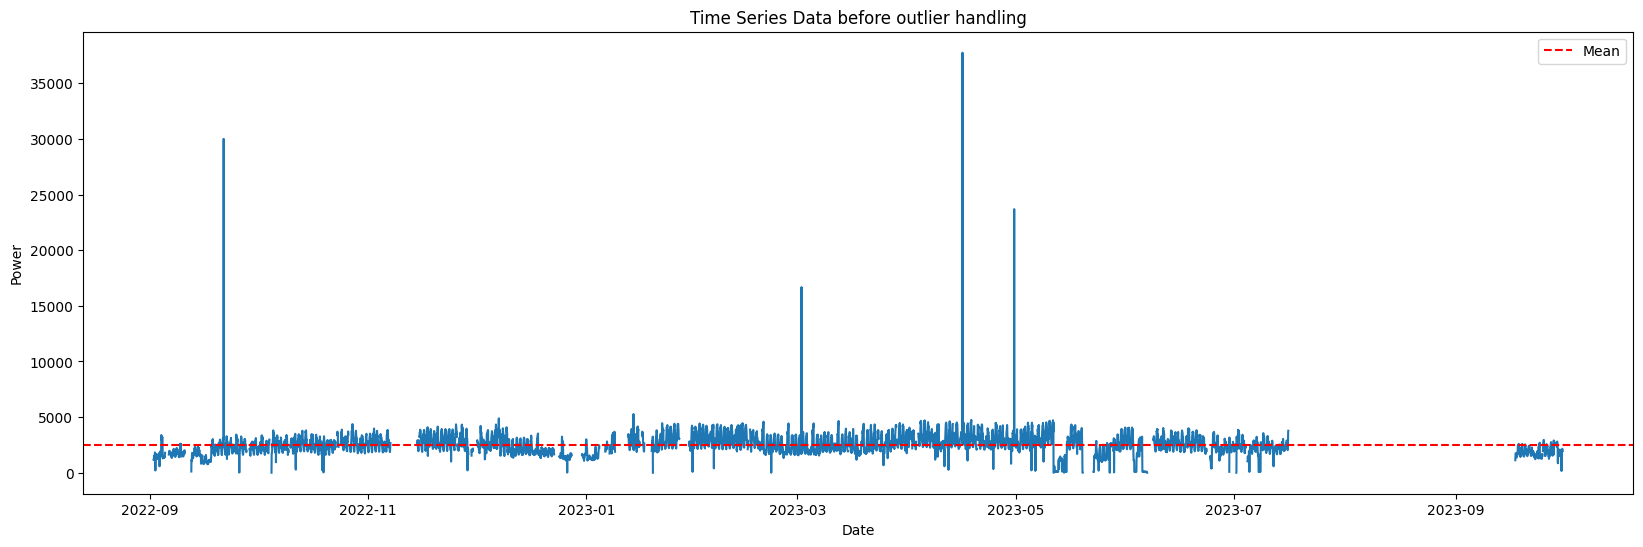

In [176]:
# Visual Inspection - Plot the data with missing values
plt.figure(figsize=(20, 6))
dataset_copy.set_index('Datetime', inplace=True)
plt.plot(dataset_copy['Power'])
plt.xlabel('Date')
plt.ylabel('Power')
plt.title('Time Series Data before outlier handling')
plt.axhline(y=dataset['Power'].mean(), color='r', linestyle='--', label='Mean')
plt.legend()
plt.show()

In [177]:
#handling outlier using IQR - interquantile range
upper = dataset_copy['Power'].quantile(0.75)
lower = dataset_copy['Power'].quantile(0.25)
IQR = upper - lower
max_threshold = upper + (1.5 * IQR)
min_threshold = lower - (1.5 * IQR)

In [178]:
#capping outlier
dataset_copy['Power'] = np.where(dataset_copy['Power']>max_threshold, max_threshold, np.where(dataset_copy['Power']<min_threshold, min_threshold,dataset_copy['Power'] ))

In [179]:
#fill missing value with mean
mean = dataset_copy['Power'].mean()
dataset_copy['Power']= dataset_copy['Power'].fillna(mean)
#dataset_copy.dropna(inplace=True)

In [180]:
dataset_copy.head(5)

,Year,Month,Day,Hour,Temperature,Holiday,Daytype,Power
Datetime,,,,,,,,
2022-09-01 00:00:00,2022,9,1,0,23.82,1,Thursday,2511.614075
2022-09-01 01:00:00,2022,9,1,1,23.68,1,Thursday,2511.614075
2022-09-01 02:00:00,2022,9,1,2,23.61,1,Thursday,2511.614075
2022-09-01 03:00:00,2022,9,1,3,23.56,1,Thursday,2511.614075
2022-09-01 04:00:00,2022,9,1,4,23.53,1,Thursday,2511.614075


In [181]:
dataset_copy.describe()

,Year,Month,Day,Hour,Temperature,Holiday,Power
count,9480.000000,9480.000000,9480.000000,9480.000000,9480.000000,9480.000000,9480.000000
mean,2022.691139,6.713924,15.703797,11.500000,26.583504,0.359494,2511.614075
std,0.462048,3.378693,8.786290,6.922552,1.667294,0.479877,708.941573
min,2022.000000,1.000000,1.000000,0.000000,19.480000,0.000000,353.625000
25%,2022.000000,4.000000,8.000000,5.750000,25.350000,0.000000,2146.000000
50%,2023.000000,7.000000,16.000000,11.500000,26.460000,0.000000,2511.614075
75%,2023.000000,9.000000,23.000000,17.250000,27.700000,1.000000,2782.000000
max,2023.000000,12.000000,31.000000,23.000000,31.580000,1.000000,4664.625000


In [182]:
# converts to numpy array format - without survey
X = dataset_copy.iloc[:,:-1].values
Y = dataset_copy.iloc[:,7:].values

In [186]:
#encoding categorical data - without survey
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
ct = ColumnTransformer(transformers = [('encoder', OneHotEncoder(), [6])], remainder = 'passthrough')
X =  np.array(ct.fit_transform(X))

In [125]:
# converts to numpy array format
X = dataset_copy.iloc[:,:-1].values
Y = dataset_copy.iloc[:,14:].values

In [126]:
#encoding categorical data
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
ct = ColumnTransformer(transformers = [('encoder', OneHotEncoder(), [6,7,8,9,10,11,12,13])], remainder = 'passthrough')
X =  np.array(ct.fit_transform(X))

In [187]:
#splitting Dataset into training and test
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [188]:
#splitting training into validation and train
from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

In [189]:
X_train

array([[0.0, 0.0, 0.0, ..., 12, 26.36, 0],
       [0.0, 0.0, 0.0, ..., 21, 27.12, 0],
       [0.0, 0.0, 0.0, ..., 6, 26.62, 0],
       ...,
       [0.0, 0.0, 1.0, ..., 11, 28.62, 0],
       [0.0, 0.0, 0.0, ..., 11, 28.99, 0],
       [0.0, 0.0, 1.0, ..., 17, 27.08, 0]], dtype=object)

In [190]:
#Data normalization - without survey
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train[:,11] = sc.fit_transform(X_train[:,11].reshape(-1, 1)).flatten()
X_test[:,11] = sc.fit_transform(X_test[:,11].reshape(-1, 1)).flatten()
X_val[:,11] = sc.fit_transform(X_val[:,11].reshape(-1, 1)).flatten()

In [130]:
#Data normalization
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train[:,26] = sc.fit_transform(X_train[:,26].reshape(-1, 1)).flatten()
X_test[:,26] = sc.fit_transform(X_test[:,26].reshape(-1, 1)).flatten()
X_val[:,26] = sc.fit_transform(X_val[:,26].reshape(-1, 1)).flatten()

In [191]:
y_train = y_train.flatten()
y_test = y_test.flatten()
y_val = y_val.flatten()

In [43]:
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error

In [133]:
#Initialize SVR model
svr_model = SVR(kernel='rbf', gamma='auto',   C=1000)  # Radial Basis Function (RBF) kernel

# Train the SVR model
svr_model.fit(X_train, y_train)

# Predict on the val and train set
y_train_pred = svr_model.predict(X_train)
y_val_pred = svr_model.predict(X_val)


In [134]:
# Evaluate the model
mse_train = mean_squared_error(y_train, y_train_pred)
mae_train = mean_absolute_error(y_train, y_train_pred)
mape_train = mean_absolute_percentage_error(y_train, y_train_pred)

mse_val = mean_squared_error(y_val, y_val_pred)
mae_val = mean_absolute_error(y_val, y_val_pred)
mape_val = mean_absolute_percentage_error(y_val, y_val_pred)

print("Mean Squared Error (MSE-TRAIN):", mse_train)
print("Mean Absolute Error (MAE-TRAIN):", mae_train)
print("Mean Absolute Percentage Error (MAPE-TRAIN):", mape_train)
print("-------------------------------------------------")
print("Mean Squared Error (MSE-VAL):", mse_val)
print("Mean Absolute Error (MAE-VAL):", mae_val)
print("Mean Absolute Percentage Error (MAPE-VAL):", mape_val)


Mean Squared Error (MSE-TRAIN): 82867.78706510113
Mean Absolute Error (MAE-TRAIN): 105.93863947120981
Mean Absolute Percentage Error (MAPE-TRAIN): 0.10133007801613264
-------------------------------------------------
Mean Squared Error (MSE-VAL): 165074.75653901178
Mean Absolute Error (MAE-VAL): 226.51619595614852
Mean Absolute Percentage Error (MAPE-VAL): 0.16583998368062836


In [135]:
# Predict on the test set
y_pred = svr_model.predict(X_test)

In [136]:
mse_test = mean_squared_error(y_test, y_pred)
mae_test = mean_absolute_error(y_test, y_pred)
mape_test = mean_absolute_percentage_error(y_test, y_pred)

print("Mean Squared Error (MSE-TEST):", mse_test)
print("Mean Absolute Error (MAE-TEST):", mae_test)
print("Mean Absolute Percentage Error (MAPE-TEST):", mape_test)

Mean Squared Error (MSE-TEST): 132694.28801263933
Mean Absolute Error (MAE-TEST): 209.5413063270683
Mean Absolute Percentage Error (MAPE-TEST): 0.13644336519564448


In [137]:
# Create a DataFrame to display actual and predicted values
results_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
print("Actual vs Predicted:")
results_df.head(10)

Actual vs Predicted:


,Actual,Predicted
0,353.625000,1340.810155
1,2116.000000,2172.130522
2,2511.614075,2484.390665
3,4049.000000,3448.718799
4,2409.000000,1413.463364
5,1425.000000,1691.215604
6,3475.000000,3543.919763
7,2511.614075,2447.991279
8,1909.000000,1802.520015
9,4110.000000,4096.040967


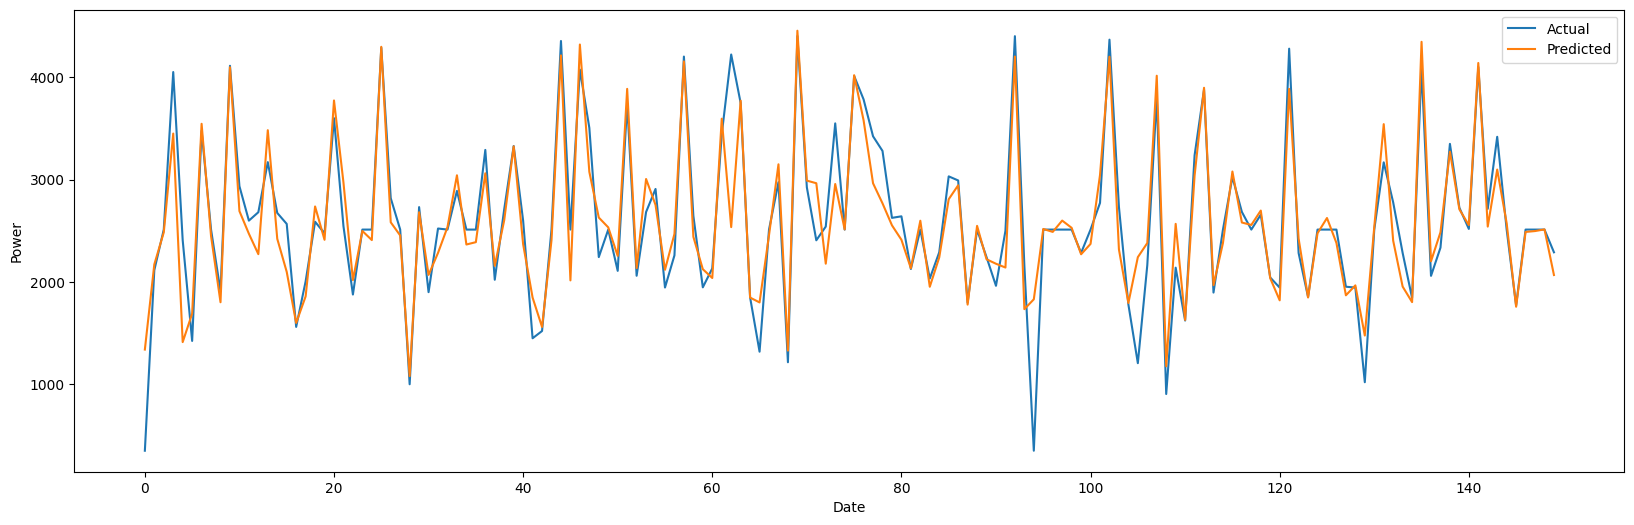

In [138]:
# Visual Inspection - Plot the data with missing values
plt.figure(figsize=(20, 6))
plt.plot(results_df['Actual'].head(150), label="Actual")
plt.plot(results_df['Predicted'].head(150), label="Predicted")
plt.xlabel('Date')
plt.ylabel('Power')
plt.legend()
plt.show()


In [192]:
from xgboost import XGBRegressor

# Create the XGBoost model
model = XGBRegressor(n_estimators=320, learning_rate=0.2, max_depth = 6,  early_stopping_rounds=50)  # You can adjust these hyperparameters

# Train the model
model.fit(X_train, y_train, eval_set=[(X_train, y_train),(X_val, y_val)],  verbose=True)

# Make predictions on the testing set
y_train_pred = model.predict(X_train)
y_val_pred = model.predict(X_val)
y_pred = model.predict(X_test)


[0]	validation_0-rmse:649.95452	validation_1-rmse:669.70022


[1]	validation_0-rmse:607.24924	validation_1-rmse:628.23134
[2]	validation_0-rmse:578.67448	validation_1-rmse:601.60197
[3]	validation_0-rmse:555.96490	validation_1-rmse:581.07755
[4]	validation_0-rmse:538.51804	validation_1-rmse:566.04303
[5]	validation_0-rmse:525.59757	validation_1-rmse:555.02935
[6]	validation_0-rmse:508.66839	validation_1-rmse:541.60325
[7]	validation_0-rmse:496.73376	validation_1-rmse:530.00363
[8]	validation_0-rmse:483.87564	validation_1-rmse:519.71669
[9]	validation_0-rmse:467.88836	validation_1-rmse:504.65904
[10]	validation_0-rmse:461.13982	validation_1-rmse:499.86298
[11]	validation_0-rmse:452.09884	validation_1-rmse:490.89285
[12]	validation_0-rmse:445.13691	validation_1-rmse:485.78752
[13]	validation_0-rmse:439.62881	validation_1-rmse:482.05238
[14]	validation_0-rmse:428.64911	validation_1-rmse:472.62940
[15]	validation_0-rmse:419.15516	validation_1-rmse:462.80414
[16]	validation_0-rmse:411.38721	validation_1-rmse:456.13124
[17]	validation_0-rmse:405.00423	

In [193]:
# Evaluate the model
mse_train = mean_squared_error(y_train, y_train_pred)
mae_train = mean_absolute_error(y_train, y_train_pred)
mape_train = mean_absolute_percentage_error(y_train, y_train_pred)

mse_val = mean_squared_error(y_val, y_val_pred)
mae_val = mean_absolute_error(y_val, y_val_pred)
mape_val = mean_absolute_percentage_error(y_val, y_val_pred)

mse_test = mean_squared_error(y_test, y_pred)
mae_test = mean_absolute_error(y_test, y_pred)
mape_test = mean_absolute_percentage_error(y_test, y_pred)

print("Mean Squared Error (MSE-TRAIN):", mse_train)
print("Mean Absolute Error (MAE-TRAIN):", mae_train)
print("Mean Absolute Percentage Error (MAPE-TRAIN):", mape_train)
print("-------------------------------------------------")
print("Mean Squared Error (MSE-VAL):", mse_val)
print("Mean Absolute Error (MAE-VAL):", mae_val)
print("Mean Absolute Percentage Error (MAPE-VAL):", mape_val)
print("-------------------------------------------------")
print("Mean Squared Error (MSE-TEST):", mse_test)
print("Mean Absolute Error (MAE-TEST):", mae_test)
print("Mean Absolute Percentage Error (MAPE-TEST):", mape_test)

Mean Squared Error (MSE-TRAIN): 11281.657547320407
Mean Absolute Error (MAE-TRAIN): 73.09288486384078
Mean Absolute Percentage Error (MAPE-TRAIN): 0.03912601062830083
-------------------------------------------------
Mean Squared Error (MSE-VAL): 115535.63553716235
Mean Absolute Error (MAE-VAL): 219.24315173067322
Mean Absolute Percentage Error (MAPE-VAL): 0.12557993238882065
-------------------------------------------------
Mean Squared Error (MSE-TEST): 114796.75356904737
Mean Absolute Error (MAE-TEST): 217.9403061198066
Mean Absolute Percentage Error (MAPE-TEST): 0.11545922401225418


In [195]:
# Create a DataFrame to display actual and predicted values---xgboost
results_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
print("Actual vs Predicted:")
results_df.head(10)

Actual vs Predicted:


,Actual,Predicted
0,353.625000,802.714233
1,2116.000000,2245.569824
2,2511.614075,2553.173096
3,4049.000000,3319.042480
4,2409.000000,2262.253906
5,1425.000000,1627.653931
6,3475.000000,3406.169922
7,2511.614075,2654.459229
8,1909.000000,1861.038818
9,4110.000000,4241.838867


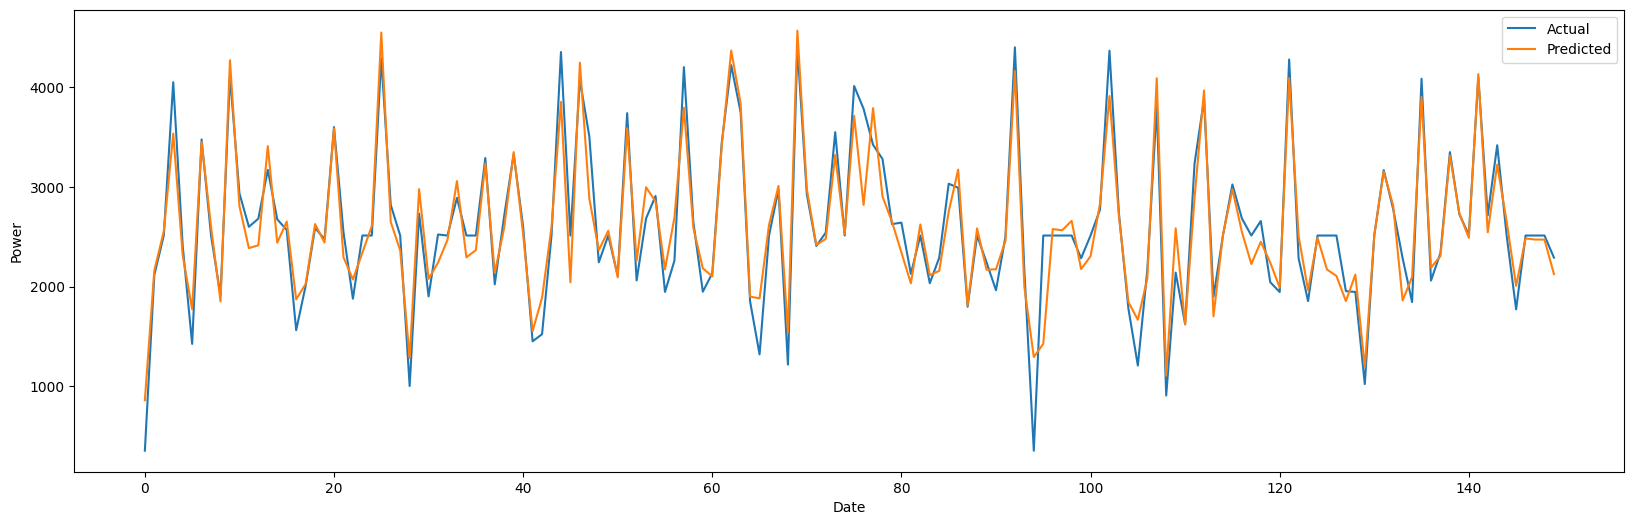

In [142]:
# Visual Inspection - Plot the data with missing values
plt.figure(figsize=(20, 6))
plt.plot(results_df['Actual'].head(150), label="Actual")
plt.plot(results_df['Predicted'].head(150), label="Predicted")
plt.xlabel('Date')
plt.ylabel('Power')
plt.legend()
plt.show()

In [197]:
# Import libraries
from sklearn.ensemble import RandomForestRegressor

# Create the Random Forest model
model = RandomForestRegressor(n_estimators=235, max_depth= 23, random_state=42)  # You can adjust hyperparameters like n_estimators

# Train the model
model.fit(X_train, y_train)

# Make predictions on the testing set
y_train_pred = model.predict(X_train)
y_val_pred = model.predict(X_val)
y_pred = model.predict(X_test)

# Evaluate the model's performance (e.g., using Mean Squared Error)
mse_test = mean_squared_error(y_test, y_pred)
mae_test = mean_absolute_error(y_test, y_pred)
mape_test = mean_absolute_percentage_error(y_test, y_pred)

print("Mean Squared Error (MSE-TEST):", mse_test)
print("Mean Absolute Error (MAE-TEST):", mae_test)
print("Mean Absolute Percentage Error (MAPE-TEST):", mape_test)

Mean Squared Error (MSE-TEST): 119512.76500560906
Mean Absolute Error (MAE-TEST): 211.11272352102225
Mean Absolute Percentage Error (MAPE-TEST): 0.11719630716095736


In [198]:
# Evaluate the model
mse_train = mean_squared_error(y_train, y_train_pred)
mae_train = mean_absolute_error(y_train, y_train_pred)
mape_train = mean_absolute_percentage_error(y_train, y_train_pred)

mse_val = mean_squared_error(y_val, y_val_pred)
mae_val = mean_absolute_error(y_val, y_val_pred)
mape_val = mean_absolute_percentage_error(y_val, y_val_pred)

mse_test = mean_squared_error(y_test, y_pred)
mae_test = mean_absolute_error(y_test, y_pred)
mape_test = mean_absolute_percentage_error(y_test, y_pred)

print("Mean Squared Error (MSE-TRAIN):", mse_train)
print("Mean Absolute Error (MAE-TRAIN):", mae_train)
print("Mean Absolute Percentage Error (MAPE-TRAIN):", mape_train)
print("-------------------------------------------------")
print("Mean Squared Error (MSE-VAL):", mse_val)
print("Mean Absolute Error (MAE-VAL):", mae_val)
print("Mean Absolute Percentage Error (MAPE-VAL):", mape_val)
print("-------------------------------------------------")
print("Mean Squared Error (MSE-TEST):", mse_test)
print("Mean Absolute Error (MAE-TEST):", mae_test)
print("Mean Absolute Percentage Error (MAPE-TEST):", mape_test)

Mean Squared Error (MSE-TRAIN): 18825.28810301157
Mean Absolute Error (MAE-TRAIN): 82.75939196369386
Mean Absolute Percentage Error (MAPE-TRAIN): 0.052939023338204286
-------------------------------------------------
Mean Squared Error (MSE-VAL): 138028.9185356671
Mean Absolute Error (MAE-VAL): 226.62009735673675
Mean Absolute Percentage Error (MAPE-VAL): 0.14041653676062016
-------------------------------------------------
Mean Squared Error (MSE-TEST): 119512.76500560906
Mean Absolute Error (MAE-TEST): 211.11272352102225
Mean Absolute Percentage Error (MAPE-TEST): 0.11719630716095736


In [200]:
# Create a DataFrame to display actual and predicted values---xgboost
results_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
print("Actual vs Predicted:")
results_df.head(10)

Actual vs Predicted:


,Actual,Predicted
0,353.625000,894.299050
1,2116.000000,2211.673978
2,2511.614075,2511.614075
3,4049.000000,3011.398704
4,2409.000000,2305.507351
5,1425.000000,1653.806584
6,3475.000000,3465.843524
7,2511.614075,2645.498576
8,1909.000000,1929.451549
9,4110.000000,4154.461702


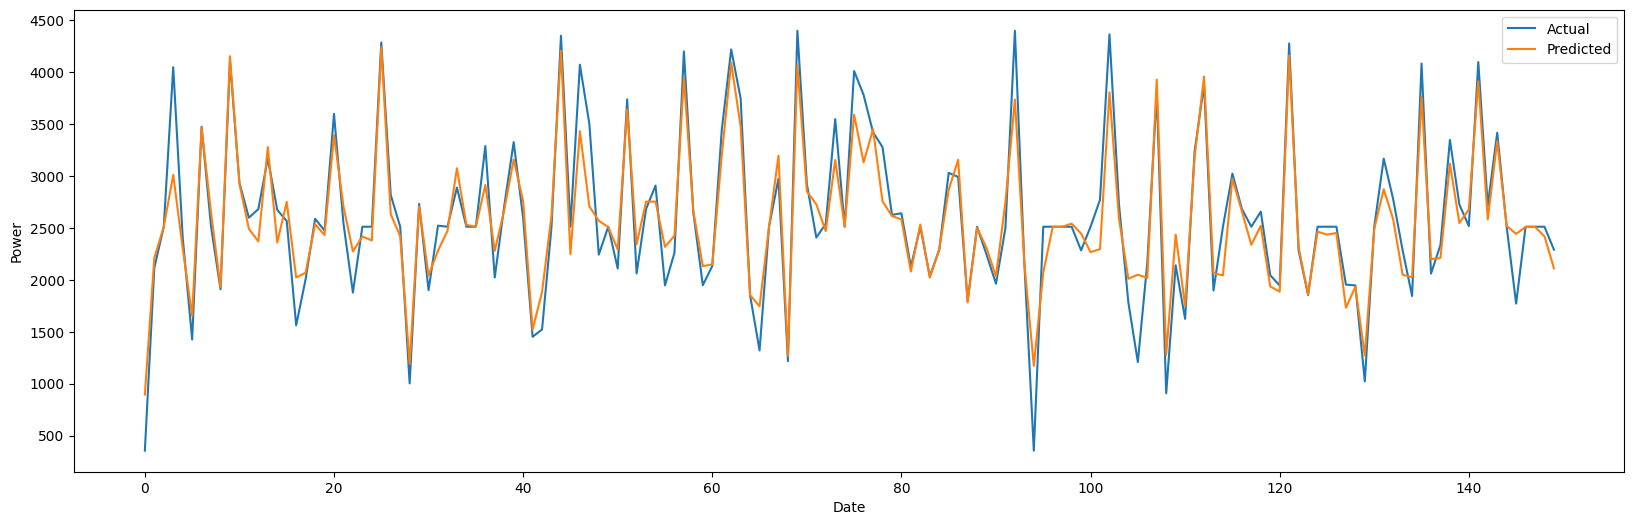

In [201]:
# Visual Inspection - Plot the data with missing values
plt.figure(figsize=(20, 6))
plt.plot(results_df['Actual'].head(150), label="Actual")
plt.plot(results_df['Predicted'].head(150), label="Predicted")
plt.xlabel('Date')
plt.ylabel('Power')
plt.legend()
plt.show()

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
import os
from sklearn.metrics import mean_squared_error
import openpyxl

pwd = os.getcwd()
dataset = pd.read_excel(pwd + "/data/DATA.xlsx")
dataset_copy = dataset.copy()

dataset_copy.drop(['Time', 'Date', 'Frequency of use [Cooker]',	'Frequency of use [Light]',	'Frequency of use [Laptop]','Frequency of use [Kettle]',	'Frequency of use [Fan]'	,'Frequency of use [Ipod/Tab/Phone]',	'Frequency of use in a day [Iron]'	], inplace=True, axis=1)

#handling outlier using IQR - interquantile range
upper = dataset_copy['Power'].quantile(0.75)
lower = dataset_copy['Power'].quantile(0.25)
IQR = upper - lower
max_threshold = upper + (1.5 * IQR)
min_threshold = lower - (1.5 * IQR)

dataset_copy['Power'] = np.where(dataset_copy['Power']>max_threshold, max_threshold, np.where(dataset_copy['Power']<min_threshold, min_threshold,dataset_copy['Power'] ))

#fill missing value with mean
mean = dataset_copy['Power'].mean()
dataset_copy['Power']= dataset_copy['Power'].fillna(mean)

#One-hot encoding for day-type
data = pd.get_dummies(dataset_copy, columns=['Daytype'])


# Select relevant features for modeling
features = ['Year'	,'Month',	'Day',	'Hour',	'Temperature',	'Holiday',	'Daytype_Friday',	'Daytype_Monday',	'Daytype_Saturday',	'Daytype_Sunday',	'Daytype_Thursday',	'Daytype_Tuesday',	'Daytype_Wednesday',	'Power']  # Replace with your feature names
load_data = data[features].values

# Normalize data
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_load_data = scaler.fit_transform(load_data)

# Split data into train and test sets
train_size = int(len(scaled_load_data) * 0.8)
test_size = len(scaled_load_data) - train_size
train_data, test_data = scaled_load_data[0:train_size, :], scaled_load_data[train_size:len(scaled_load_data), :]

# Function to create dataset with look back
def create_sequences(dataset, time_steps=1):
    X, Y = [], []
    mse_values = []  # List to store MSE values
    for i in range(len(dataset) - time_steps - 1):
        a = dataset[i:(i + time_steps), :-1]
        X.append(a)
        target_index = i + time_steps
        target_value = dataset[target_index, -1]  # Assuming the target variable is in the last column
        Y.append(target_value)
        
        # Calculate MSE
        predicted_value = dataset[i + time_steps, -1]  # Assuming the predicted value is the same as the target value
        mse = mean_squared_error([target_value], [predicted_value])
        mse_values.append(mse)
        
        # Print MSE
        print(f"MSE at index {target_index}: {mse}")

    return np.array(X), np.array(Y), np.array(mse_values)

look_back = 24  # Number of previous time steps to use as input features

# Create dataset with look back
X_train, Y_train, mseTrain = create_sequences(train_data, look_back)
X_test, Y_test, mseTest = create_sequences(test_data, look_back)

# Define LSTM model
model = Sequential()
model.add(LSTM(units=50, input_shape=(look_back, len(features))))
model.add(Dense(units=1))  # Output layer with 1 neuron for regression
model.compile(optimizer='adam', loss='mean_squared_error')

# Train the model
model.fit(X_train, Y_train, epochs=100, batch_size=32)

# Make predictions
train_predict = model.predict(X_train)
test_predict = model.predict(X_test)

# Inverse transform predictions
train_predict = scaler.inverse_transform(train_predict)
test_predict = scaler.inverse_transform(test_predict)

# Plot actual vs predicted values
plt.plot(data['load'].values, label='Actual Load')
plt.plot(np.concatenate([train_predict, test_predict]), label='Predicted Load')
plt.legend()
plt.show()

print(mseTrain)
print(mseTest)

MSE at index 24: 0.0
MSE at index 25: 0.0
MSE at index 26: 0.0
MSE at index 27: 0.0
MSE at index 28: 0.0
MSE at index 29: 0.0
MSE at index 30: 0.0
MSE at index 31: 0.0
MSE at index 32: 0.0
MSE at index 33: 0.0
MSE at index 34: 0.0
MSE at index 35: 0.0
MSE at index 36: 0.0
MSE at index 37: 0.0
MSE at index 38: 0.0
MSE at index 39: 0.0
MSE at index 40: 0.0
MSE at index 41: 0.0
MSE at index 42: 0.0
MSE at index 43: 0.0
MSE at index 44: 0.0
MSE at index 45: 0.0
MSE at index 46: 0.0
MSE at index 47: 0.0
MSE at index 48: 0.0
MSE at index 49: 0.0
MSE at index 50: 0.0
MSE at index 51: 0.0
MSE at index 52: 0.0
MSE at index 53: 0.0
MSE at index 54: 0.0
MSE at index 55: 0.0
MSE at index 56: 0.0
MSE at index 57: 0.0
MSE at index 58: 0.0
MSE at index 59: 0.0
MSE at index 60: 0.0
MSE at index 61: 0.0
MSE at index 62: 0.0
MSE at index 63: 0.0
MSE at index 64: 0.0
MSE at index 65: 0.0
MSE at index 66: 0.0
MSE at index 67: 0.0
MSE at index 68: 0.0
MSE at index 69: 0.0
MSE at index 70: 0.0
MSE at index 

c:\Users\HP\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\rnn\rnn.py:205: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/100


ValueError: Exception encountered when calling LSTMCell.call().

[1mDimensions must be equal, but are 13 and 14 for '{{node sequential_1/lstm_1/lstm_cell_1/MatMul}} = MatMul[T=DT_FLOAT, grad_a=false, grad_b=false, transpose_a=false, transpose_b=false](sequential_1/lstm_1/strided_slice_2, sequential_1/lstm_1/lstm_cell_1/Cast/ReadVariableOp)' with input shapes: [?,13], [14,200].[0m

Arguments received by LSTMCell.call():
  • inputs=tf.Tensor(shape=(None, 13), dtype=float32)
  • states=('tf.Tensor(shape=(None, 50), dtype=float32)', 'tf.Tensor(shape=(None, 50), dtype=float32)')
  • training=True